# Carregar os Dados

In [1]:
import pandas as pd
import numpy as np
from plotly import express as px

color_palette = px.colors.qualitative.Alphabet

In [2]:
vehicles = pd.read_csv('../vehicles.csv')

vehicles.head()

,price,model_year,model,condition,cylinders,fuel,odometer,transmission,type,paint_color,is_4wd,date_posted,days_listed
0,9400,2011.0,bmw x5,good,6.0,gas,145000.0,automatic,SUV,NaN,1.0,2018-06-23,19
1,25500,NaN,ford f-150,good,6.0,gas,88705.0,automatic,pickup,white,1.0,2018-10-19,50
2,5500,2013.0,hyundai sonata,like new,4.0,gas,110000.0,automatic,sedan,red,NaN,2019-02-07,79
3,1500,2003.0,ford f-150,fair,8.0,gas,NaN,automatic,pickup,NaN,NaN,2019-03-22,9
4,14900,2017.0,chrysler 200,excellent,4.0,gas,80903.0,automatic,sedan,black,NaN,2019-04-02,28


In [3]:
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51525 entries, 0 to 51524
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         51525 non-null  int64  
 1   model_year    47906 non-null  float64
 2   model         51525 non-null  object 
 3   condition     51525 non-null  object 
 4   cylinders     46265 non-null  float64
 5   fuel          51525 non-null  object 
 6   odometer      43633 non-null  float64
 7   transmission  51525 non-null  object 
 8   type          51525 non-null  object 
 9   paint_color   42258 non-null  object 
 10  is_4wd        25572 non-null  float64
 11  date_posted   51525 non-null  object 
 12  days_listed   51525 non-null  int64  
dtypes: float64(4), int64(2), object(7)
memory usage: 5.1+ MB


In [4]:
print(vehicles.duplicated().sum())

0


Vemos que temos varios dados ausentes em colunas como ano, cor, e odômetro. Provavelmente, os anúncios desses carros simplesmente não incluíram essas informações. Vamos ter que seguir com a análise e lidar com os dados ausentes caso a caso. Pelo menos, não há duplicatas.

Vamos agora agregar aos dados.

In [5]:
vehicles['date_posted'] = pd.to_datetime(vehicles['date_posted'], format='%Y-%m-%d')

In [6]:
vehicles['brand'] = vehicles['model'].apply(lambda x: x.split()[0])

In [7]:
vehicles.sample(20)

,price,model_year,model,condition,cylinders,fuel,odometer,transmission,type,paint_color,is_4wd,date_posted,days_listed,brand
26791,16950,2011.0,gmc sierra 1500,good,8.0,gas,36057.0,automatic,truck,red,1.0,2018-12-07,19,gmc
5451,19990,2010.0,ford f-350 sd,good,10.0,gas,51664.0,manual,truck,white,1.0,2018-06-20,24,ford
40984,15000,2002.0,gmc sierra,good,8.0,gas,105000.0,automatic,other,orange,NaN,2018-05-31,6,gmc
49904,5200,2016.0,nissan versa,excellent,4.0,gas,69725.0,manual,sedan,silver,NaN,2018-10-11,55,nissan
25824,7200,2008.0,chevrolet silverado 1500,like new,6.0,gas,128066.0,automatic,truck,white,NaN,2019-03-25,3,chevrolet
21740,5697,2009.0,toyota camry,excellent,4.0,gas,NaN,automatic,sedan,blue,1.0,2018-06-06,37,toyota
10936,5999,2009.0,hyundai santa fe,excellent,6.0,gas,127000.0,automatic,SUV,NaN,1.0,2019-01-04,25,hyundai
17203,6995,NaN,ford edge,excellent,6.0,gas,88108.0,automatic,sedan,black,1.0,2018-06-27,31,ford
39732,11999,2008.0,ram 1500,excellent,8.0,gas,152862.0,automatic,pickup,black,1.0,2019-04-17,25,ram
17096,23900,2015.0,nissan murano,excellent,6.0,gas,38000.0,automatic,SUV,silver,1.0,2018-09-19,106,nissan


Transformamos a coluna de datas no tipo `DateTime` e adicionamos uma coluna para a marca dos carros.

# Análise dos Dados

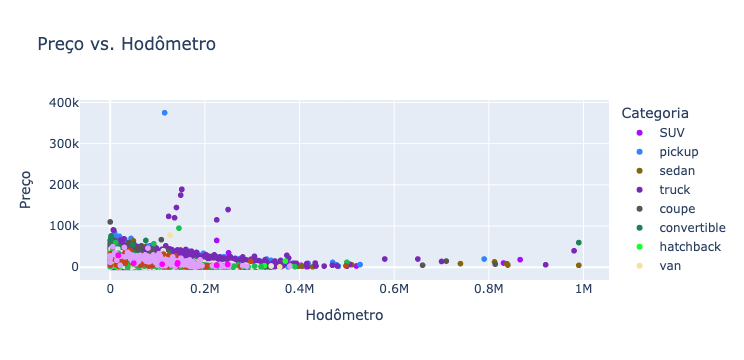

In [17]:
fig = px.scatter(
    vehicles[~vehicles["odometer"].isna()], 
    x="odometer", 
    y="price", 
    color="type", 
    title="Preço vs. Hodômetro",
    labels={'odometer': 'Hodômetro', 'price': 'Preço', 'type': 'Categoria'},
    color_discrete_sequence=color_palette
)

fig.show()

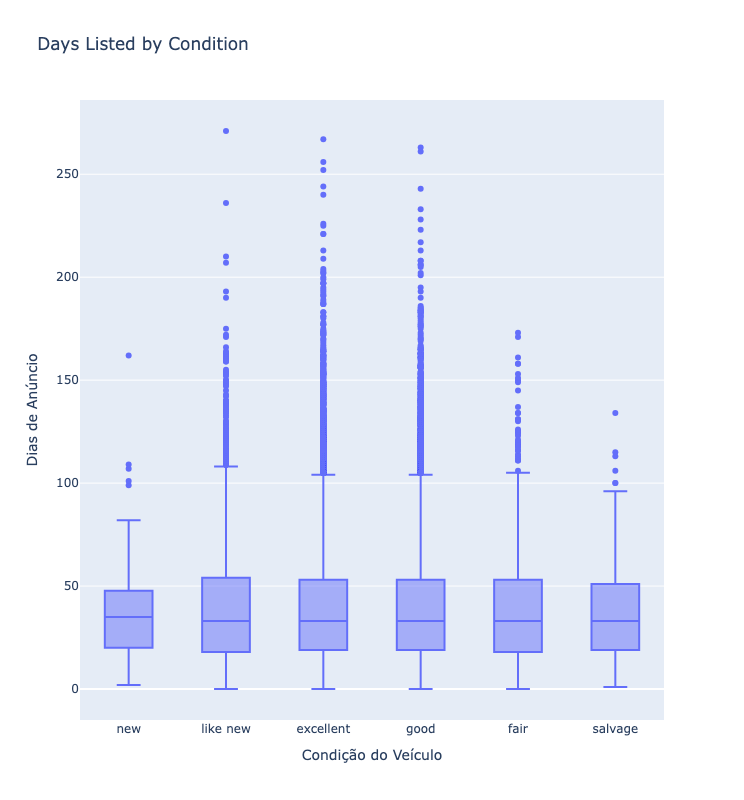

In [16]:
fig = px.box(
    vehicles, 
    x="condition", 
    y="days_listed", 
    title="Days Listed by Condition",
    width=800,
    height=800,
    labels={'days_listed': 'Dias de Anúncio', 'condition': 'Condição do Veículo'},
    category_orders={"condition": ['new', 'like new', 'excellent', 'good', 'fair', 'salvage']}
)

fig.show()

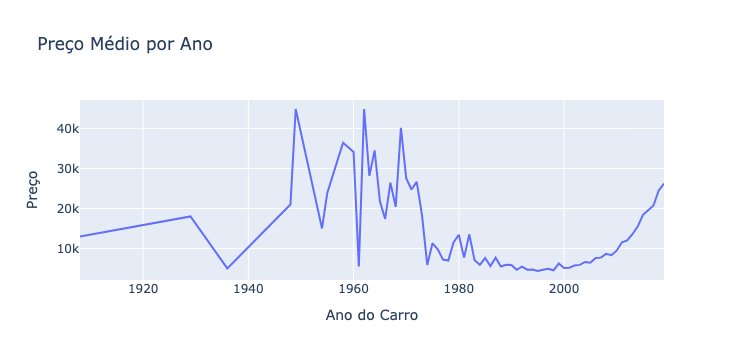

In [15]:
avg_price_year = vehicles.groupby('model_year')['price'].mean().reset_index()
fig = px.line(
    avg_price_year, 
    x="model_year", 
    y="price", 
    title="Preço Médio por Ano",
    labels={'price': 'Preço', 'model_year': 'Ano do Carro'}
)

fig.show()

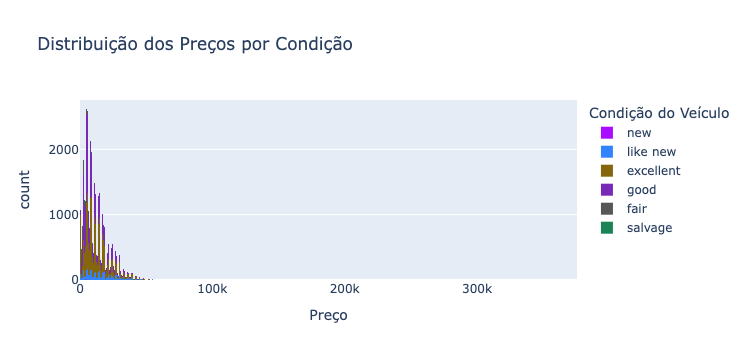

In [14]:
fig = px.histogram(
    vehicles, 
    x="price", 
    color="condition", 
    title="Distribuição dos Preços por Condição",
    category_orders={"condition": ['new', 'like new', 'excellent', 'good', 'fair', 'salvage']},
    labels={'count': 'Quantidade de Anúncios', 'price': 'Preço', 'condition': 'Condição do Veículo'},
    color_discrete_sequence=color_palette
)

fig.show()

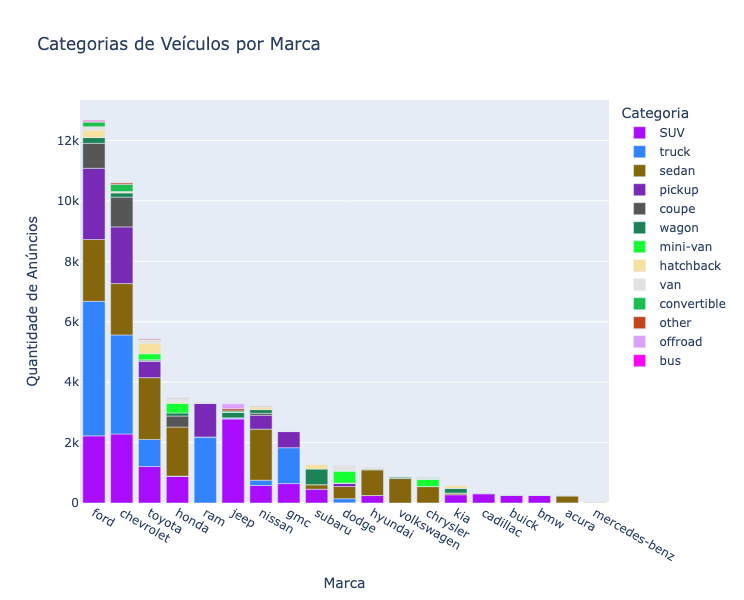

In [13]:
type_counts = vehicles.groupby(['brand', 'type']).size().reset_index(name='count')

brand_order = vehicles['brand'].value_counts().index.tolist()
type_order = vehicles['type'].value_counts().index.tolist()

fig = px.bar(
    type_counts, 
    x="brand", 
    y="count", 
    color="type",
    title="Categorias de Veículos por Marca",
    labels={'brand': 'Marca', 'count': 'Quantidade de Anúncios', 'type': 'Categoria'},
    category_orders={"brand": brand_order, "type": type_order},
    color_discrete_sequence=color_palette,
    height=600
)

fig.show()